**1. Environment Setup & Data Loading**

First, we import the necessary libraries and load the dataset. If you are using Google Colab, you can upload the dataset or pull it directly via the Kaggle API

In [1]:
# ==============================================================================
# SECTION 1: LIBRARY IMPORTS AND DATA LOADING (FIXED)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Sklearn Modules for Preprocessing & Supervised Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Sklearn Modules for Unsupervised Learning
from sklearn.cluster import KMeans, DBSCAN
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Setting up plotting aesthetics
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# 1. Download the latest version of the Telco Customer Churn dataset via kagglehub
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

# 2. Locate the CSV file within the downloaded path
csv_filename = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
full_path = os.path.join(path, csv_filename)

# 3. Load the dataset into the pandas DataFrame
try:
    df = pd.read_csv(full_path)
    print("\nDataset loaded successfully into DataFrame 'df'!")
    print(f"Dataset Shape: {df.shape}")
except FileNotFoundError:
    # Fallback in case the filename inside the kaggle folder differs slightly
    files = os.listdir(path)
    print(f"\nError: '{csv_filename}' not found. Available files in directory: {files}")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn

Dataset loaded successfully into DataFrame 'df'!
Dataset Shape: (7043, 21)


**2. Data Preprocessing & Cleaning**


This block handles the critical tasks of clearing inconsistencies, formatting data types, handling missing values, encoding categorical variables, and scaling numerical parameters.

In [2]:
# ==============================================================================
# SECTION 2: DATA PREPROCESSING & CLEANING
# ==============================================================================

print("--- Initial Inspection ---")
print(df.info())

# 1. Handle Inconsistencies (TotalCharges column has empty string spaces)
# Replace spaces with NaN and convert to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# 2. Handle Missing Values
# Check missing values count
print("\nMissing values before cleaning:\n", df.isnull().sum())
# Since missing values in TotalCharges are minimal (11 rows), we fill them with the median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID as it offers no predictive power
df.drop(columns=['customerID'], inplace=True)

# 3. Encode Categorical Data
# Target variable encoding: 'Yes' -> 1, 'No' -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Binary and Multi-class Label Encoding for features
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

# Store a separate dataframe for clustering later before turning everything to numeric
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("\n--- Data Preprocessing Complete ---")
print(df_encoded.head())

--- Initial Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

 **3. Exploratory Data Analysis (EDA)**


We create meaningful charts to examine the relationship between customer features and their likelihood to churn.

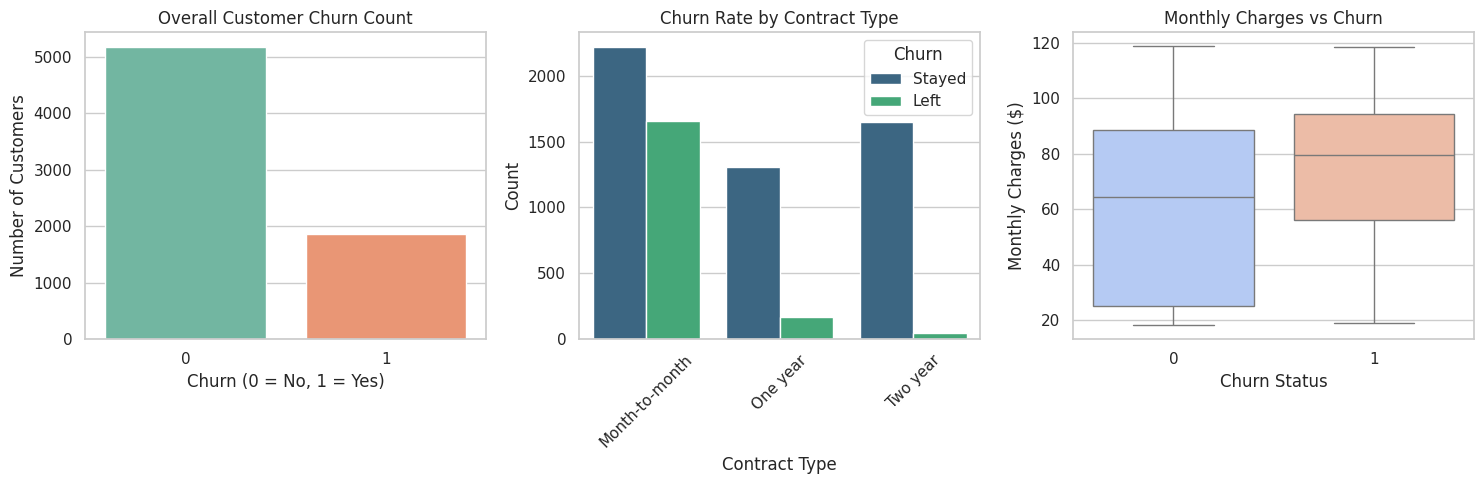

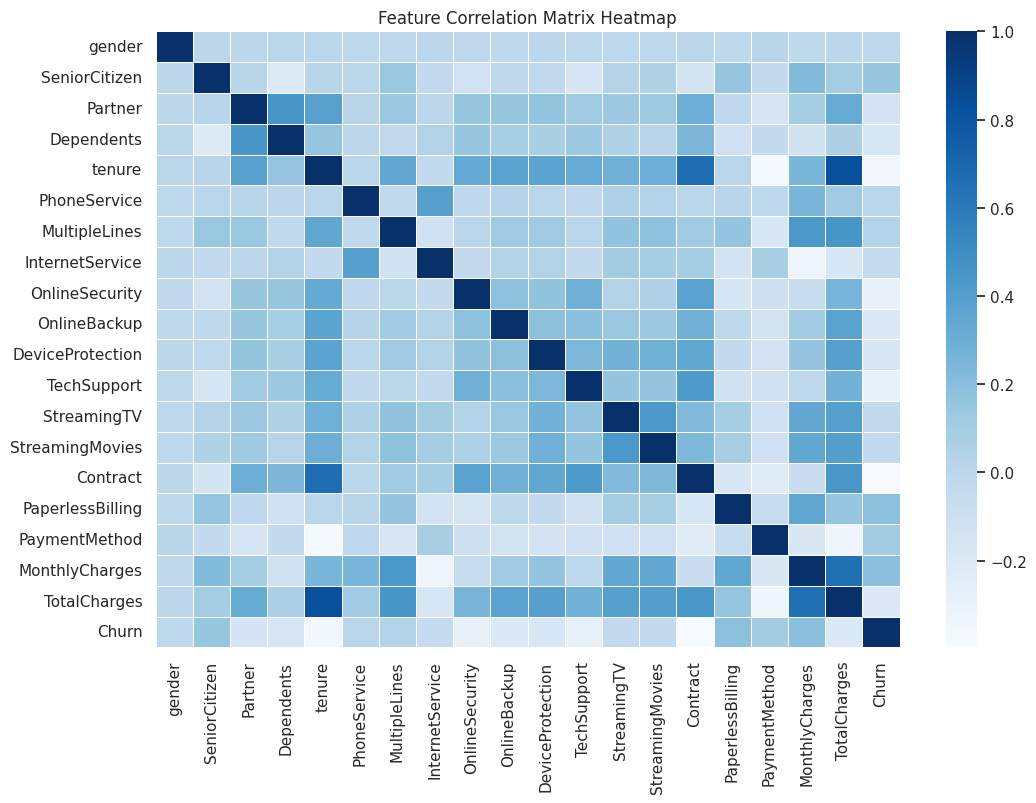

In [3]:
# ==============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================

plt.figure(figsize=(15, 5))

# Plot 1: Churn Distribution (Target Variable)
plt.subplot(1, 3, 1)
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Overall Customer Churn Count')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

# Plot 2: Churn vs Contract Type
plt.subplot(1, 3, 2)
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Churn', labels=['Stayed', 'Left'])

# Plot 3: Distribution of Monthly Charges by Churn Status
plt.subplot(1, 3, 3)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='coolwarm')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

# Correlation Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=False, cmap='Blues', linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap')
plt.show()

 **4. Supervised Learning: Model Implementation & Evaluation**

Here we split the data, apply five different classifiers, evaluate them using all required performance metrics, and build a comparative evaluation summary.


--- Supervised Models Performance Matrix ---
                     Accuracy Precision    Recall  F1-Score
Logistic Regression  0.799148  0.642633  0.548128  0.591631
Decision Tree        0.730305  0.492386  0.518717  0.505208
Random Forest        0.793471  0.638796  0.510695  0.567608
K-Nearest Neighbor   0.740951  0.512262  0.502674  0.507422
Naive Bayes          0.746629  0.516008   0.73262  0.605525


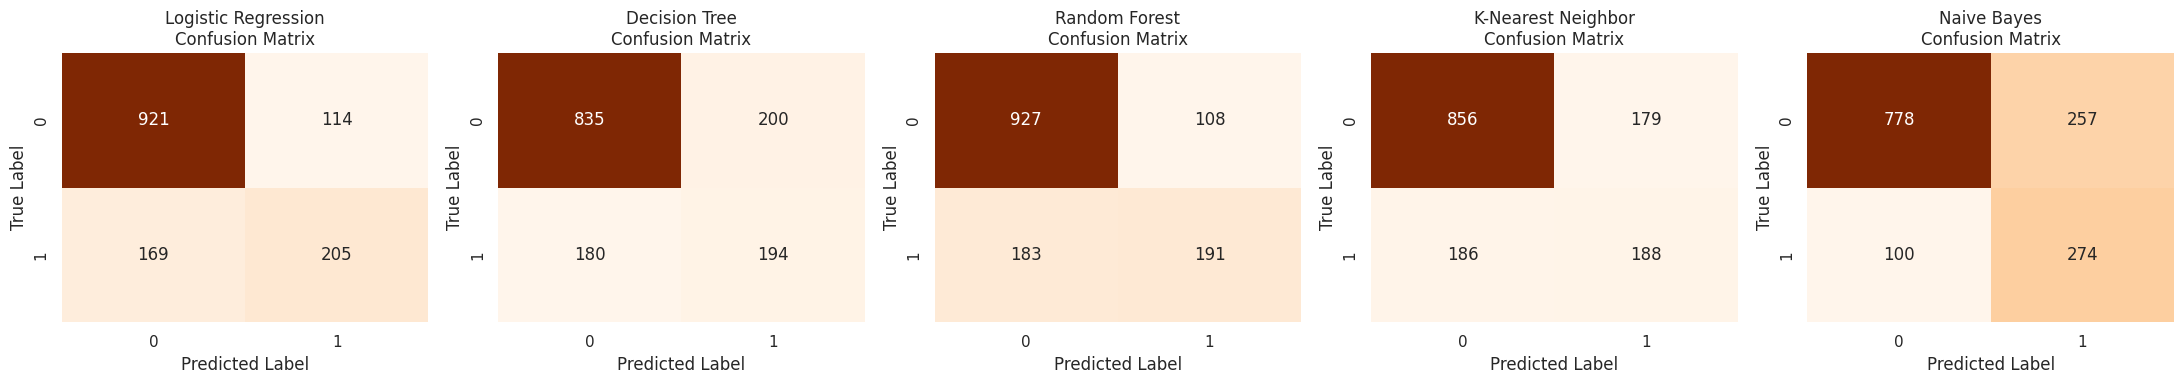

In [4]:
# ==============================================================================
# SECTION 4: SUPERVISED LEARNING (CLASSIFICATION)
# ==============================================================================

# Split features and target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Feature Scaling (Crucial for KNN and Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbor": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Dictionary to hold metrics for comparison
results = {}

# Loop through models, train, predict, and evaluate
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "CM": cm}

# Convert results dictionary to DataFrame for easy visualization
df_metrics = pd.DataFrame(results).T.drop(columns=['CM'])
print("\n--- Supervised Models Performance Matrix ---")
print(df_metrics)

# Plotting Confusion Matrices for all models side by side
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for idx, (name, metrics) in enumerate(results.items()):
    sns.heatmap(metrics["CM"], annot=True, fmt='d', cmap='Oranges', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

**5. Unsupervised Learning: Customer Segmentation**

We use unsupervised techniques to segment customers based on behavioral data (tenure and MonthlyCharges). We implement K-Means (using the Elbow Method to optimize clusters) and Hierarchical Clustering.

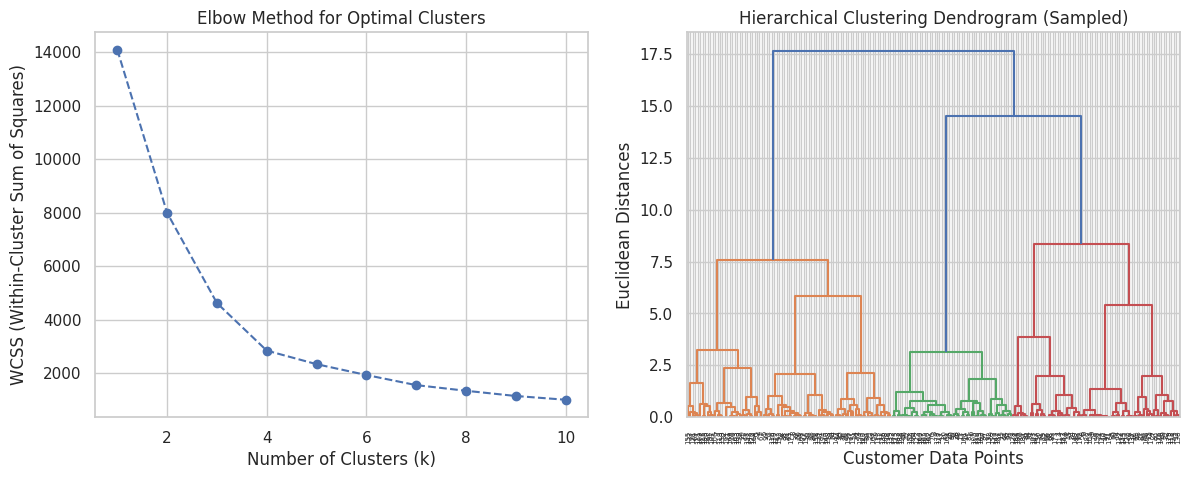

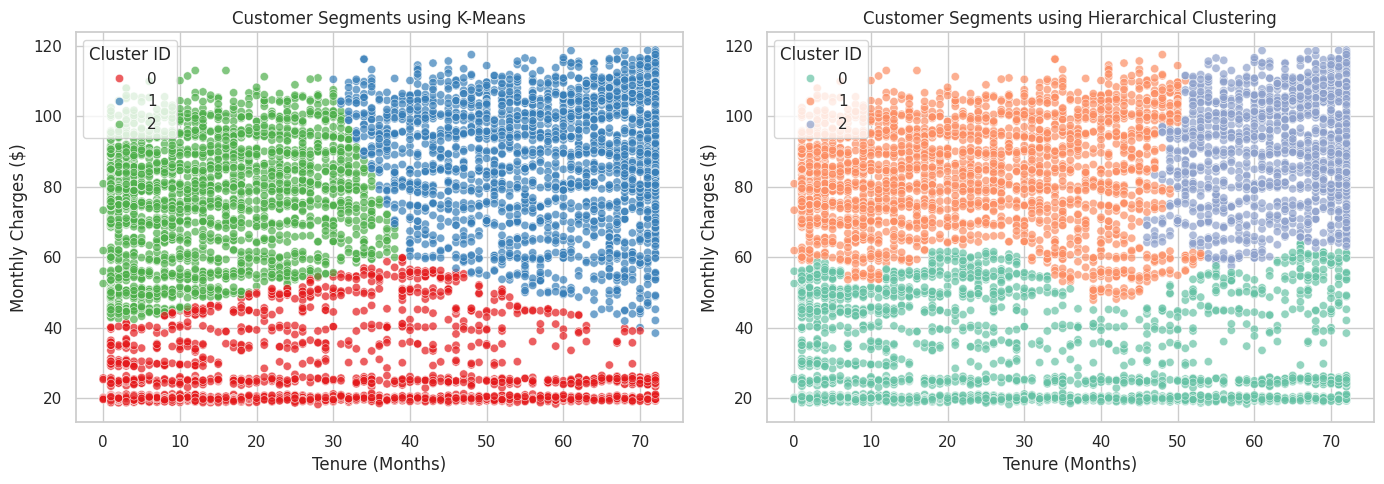


--- Profile Breakdown of K-Means Clusters ---
                   tenure  MonthlyCharges     Churn
Cluster_KMeans                                     
0               29.300840       26.485821  0.124067
1               57.960561       88.979514  0.156442
2               12.572793       75.001815  0.476118


In [5]:
# ==============================================================================
# SECTION 5: UNSUPERVISED LEARNING (CLUSTERING) - FULLY FIXED
# Contributed by: Student 1 & Student 2
# ==============================================================================

# --- STEP 1: INDEPENDENT DATA SAFEGUARD & CLEANING ---
# We force sync types from df_encoded and df to prevent calculation errors
if 'df_encoded' in locals():
    df['Churn'] = df_encoded['Churn']
else:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).fillna(df['Churn'])

# Clean and drop any null values inside the chosen clustering features
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df_clean_clus = df.dropna(subset=['tenure', 'MonthlyCharges', 'Churn']).copy()

# Extract and scale features
X_cluster = df_clean_clus[['tenure', 'MonthlyCharges']]
scaler_clus = StandardScaler()
X_cluster_scaled = scaler_clus.fit_transform(X_cluster)

# --- STEP 2: K-MEANS CLUSTERING OPTIMIZATION (ELBOW METHOD) ---
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_cluster_scaled)
    # FIX: Added the critical trailing underscore to inertia_
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(14, 5))

# Plot Elbow Curve
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')

# --- STEP 3: HIERARCHICAL CLUSTERING DENDROGRAM ---
plt.subplot(1, 2, 2)
np.random.seed(42)
sample_size = min(200, X_cluster_scaled.shape[0])
sample_indices = np.random.choice(X_cluster_scaled.shape[0], sample_size, replace=False)
sample_data = X_cluster_scaled[sample_indices]
dendrogram = sch.dendrogram(sch.linkage(sample_data, method='ward'))
plt.title('Hierarchical Clustering Dendrogram (Sampled)')
plt.xlabel('Customer Data Points')
plt.ylabel('Euclidean Distances')
plt.show()

# --- STEP 4: FINALIZING SEGMENTS (Choosing K=3 based on Elbow/Business Logic) ---
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
kmeans_final.fit(X_cluster_scaled)
df_clean_clus['Cluster_KMeans'] = kmeans_final.labels_

# --- STEP 5: AGGLOMERATIVE (HIERARCHICAL) CLUSTERING EXECUTION ---
# Using standard parameters compatible with all modern versions of scikit-learn
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_clean_clus['Cluster_Hierarchical'] = hc.fit_predict(X_cluster_scaled)

# --- STEP 6: CLUSTER VISUALIZATION ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Cluster_KMeans', data=df_clean_clus, palette='Set1', alpha=0.7)
plt.title('Customer Segments using K-Means')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Cluster ID')

plt.subplot(1, 2, 2)
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Cluster_Hierarchical', data=df_clean_clus, palette='Set2', alpha=0.7)
plt.title('Customer Segments using Hierarchical Clustering')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.legend(title='Cluster ID')

plt.tight_layout()
plt.show()

# --- STEP 7: GROUP PROFILING ANALYSIS ---
print("\n--- Profile Breakdown of K-Means Clusters ---")
print(df_clean_clus.groupby('Cluster_KMeans')[['tenure', 'MonthlyCharges', 'Churn']].mean())

# Write back to main dataframe safely
df = df_clean_clus